Inputs shape: (15, 2)
Outputs shape: (15,)
First 20 rows of raw data:
    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
14    0.469395    1.050091     -6.688485e-142  week-5
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
2025-12-10 17-40-11
Outputs will be written to: results/run_2025-1

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 1.275110, Val Loss: 0.143778
Epoch 50/500, Train Loss: 0.804995, Val Loss: 0.071495
Early stopping at epoch 88, best val_loss=0.039900


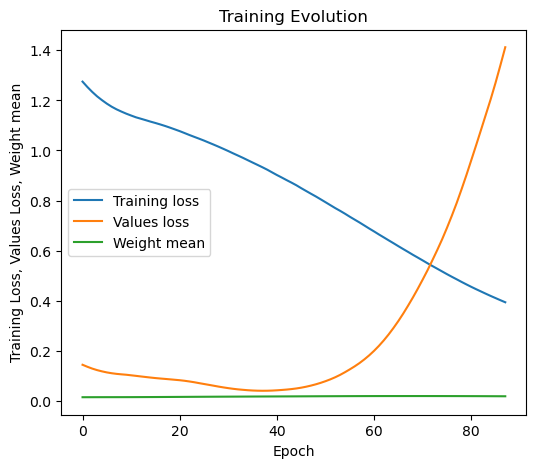

Using 2 dimensions, grid size per axis: 100, downsample: False, stride: 2
Points before downsampling: 10000
Points after downsampling: 10000
Final grid shape: (10000, 2)
Filtered 215 candidates near decision boundary (|margin| < 0.2)
Excluded 9785 candidates from consideration
Final grid shape after filtering: (215, 2)
Predictions range (scaled): -0.3028 to 0.3177
Inverse-transforming predictions to raw units
Predictions range (raw): -0.0005 to 0.0000
Total number of points to evaluate: 5
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.47235174, 1.05508727]), 'score': 0.9991851272628975, 'dim': 2, 'predicted_y': 1.6452697e-05}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.46251447, 1.06669935]), 'score': 0.9877447535722879, 'dim': 2, 'predicted_y': 4.5363424e-05}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.46251447, 1.06669935]), 'score': 0.05044469262040405, 'dim': 2, 'predicted_y': 4.5363424e-05}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array

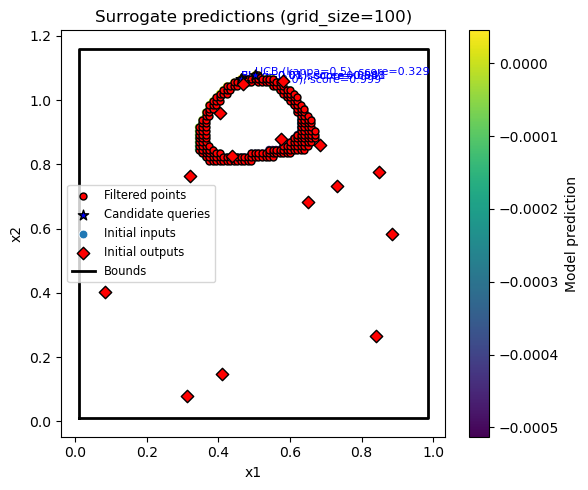

<Figure size 600x500 with 0 Axes>

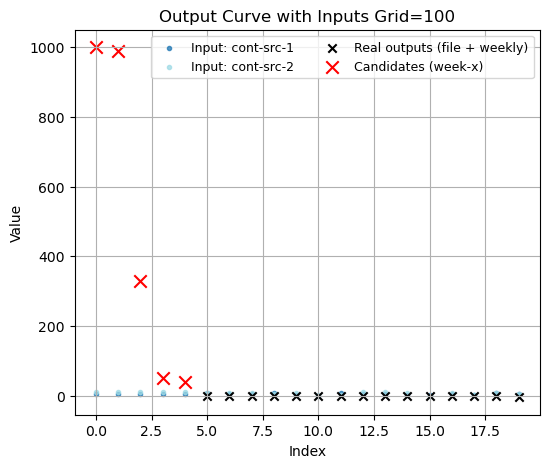

Saved dataframe to: results/run_2025-12-10 17-40-11/df_grid_100_stride2_gp_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.47235174, 1.05508727]), 'score': 0.9991851272628975, 'dim': 2, 'predicted_y': 1.6452697e-05}
    cont-src-1  cont-src-2  radiation-reading  source  radiation-reading-scaled
0     0.472352    1.055087       9.991851e-01  week-x              1.000000e+01
1     0.462514    1.066699       9.877448e-01  week-x              9.885503e+00
2     0.501864    1.078311       3.289533e-01  week-x              3.292216e+00
3     0.462514    1.066699       5.044469e-02  week-x              5.048583e-01
4     0.462514    1.066699       4.050759e-02  week-x              4.054063e-01
5     0.731024    0.733000       7.710875e-16    file              7.717164e-15
6     0.683418    0.861057       2.535001e-40    file              2.537069e-39
7     0.574329    0.879898       1.033078e-46    file              1.033921e-45
8     0.88389

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))